# Seminar "WaveNet inference" 🌊


The purpose of this seminar is to immerse you in WaveNet architecture.

<img src="https://www.researchgate.net/profile/Mark-Hasegawa-Johnson/publication/311106829/figure/fig3/AS:433958858039299@1480475262377/The-caching-scheme-for-efficient-generation-Due-to-dilated-convolutions-the-size-of-the.png" alt="Drawing" style="width: 60%;"/>

In [1]:
from IPython.display import Audio
from matplotlib import pyplot as plt
from tqdm import tqdm
import dataclasses
%matplotlib inline

from scipy.signal import lfilter
from queue import Queue

import soundfile as sf
import numpy as np
import librosa

import torch
import torch.nn as nn
from torch.nn import functional as F

## DSP utils 

"D" in "Deep Learning" stands for data and "e" for "engineering" 🙃, so we need to implement some basic data preprocessing functions.

## Pre-emphasis

Pre-emphasis filter:

$P(x) = x - \alpha * x^{-1}$, where $x^{-1}$ is $x$ shifted back to 1 time sample

De-emphasis filter:

$x = P(x) + \alpha * x^{-1}$

To increase **signal-to-noise** ratio we can add more energy to higher frequencies. Pre-emphasis filter **emphasises** higher frequencies.

<img src="https://speechprocessingbook.aalto.fi/_images/149888832.png" width="100%">

So when you feed a signal, if you apply a filter and then reverse the transform, the noise that was added to the high frequencies will end up being reduced.

<img src="https://speechprocessingbook.aalto.fi/_images/149888831.png" width="100%">

##  Mu-law

Mu encoding: 

$$
F(x) = sgn(x) \dfrac{\ln(1 + \mu |x|)}{\ln(1 + \mu)}, \quad -1 \leq x \leq 1
$$

$$ 
F(x)_{discrete} = \Bigl\lfloor \frac{1}{2} (F(x) + 1) \mu + 0.5 \Bigr\rfloor
$$ 

$$ \mu = 2^{bits} - 1, x \in (-1, 1)$$

Mu decoding: 

$$F(x) = \frac{2}{\mu} F(x)_{discrete} - 1$$

$$x = sgn(F(x)) \frac{(1 + \mu) ^ {|F(x)|} - 1}{\mu}$$

<img src="../../seminar01/quantization_mulaw.png-1.png" width="100%">

In [2]:
def plot_spectrogram(spectrogram):
    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(spectrogram, aspect="auto", origin="lower",
                   interpolation='none')
    plt.colorbar(im, ax=ax)

    fig.canvas.draw()
    plt.show()

    return fig

In [3]:
class AudioProcessor:
    MAX_WAV_VALUE = 32768.0

    def __init__(self):
        num_frequencies = 1025
        self.sample_rate = 24000
        self.window_size = int(self.sample_rate * 0.05)
        self.window_step = self.window_size // 4
        self.n_fft = (num_frequencies - 1) * 2
        self.preemphasis_coef = 0.97
        self.min_frequency = 50
        self.max_frequency = 12000
        self.num_mel_bins = 80
        self.ref_level_db = 20
        self.min_level_db = -100
        
        self.min_level = np.exp(self.min_level_db / 20 * np.log(10))
        
    def load_wav(self, path):
        wav, sr = sf.read(path, dtype=np.float32)

        assert sr == self.sample_rate
        return wav

    def pre_emphasis(self, x):
        l = [x[0]]
        l.extend(x[1:] - x[:-1] * self.preemphasis_coef )
        return np.array(l)

    def de_emphasis(self, x):
        l = [x[0]]
        for el in x[1:]:
            l.append(el + l[-1] * self.preemphasis_coef)
        return np.array(l)
    
    def amp_to_db(self, x):
        x = np.maximum(self.min_level, x)
        return 20 * np.log10(x) - self.ref_level_db

    def mu_law_encode(self, x, mu=255):
        x_mu = np.sign(x) * np.log(1 + mu * np.abs(x)) / np.log(mu + 1)
        x_mu = np.floor((x_mu + 1) / 2 * mu + 0.5)
        return x_mu

    def mu_law_decode(self, x_mu, mu=255):
        x = ((x_mu) / mu) * 2 - 1.0
        x = np.sign(x) * (np.exp(np.abs(x) * np.log(mu + 1)) - 1.0) / mu
        return x

ap = AudioProcessor()

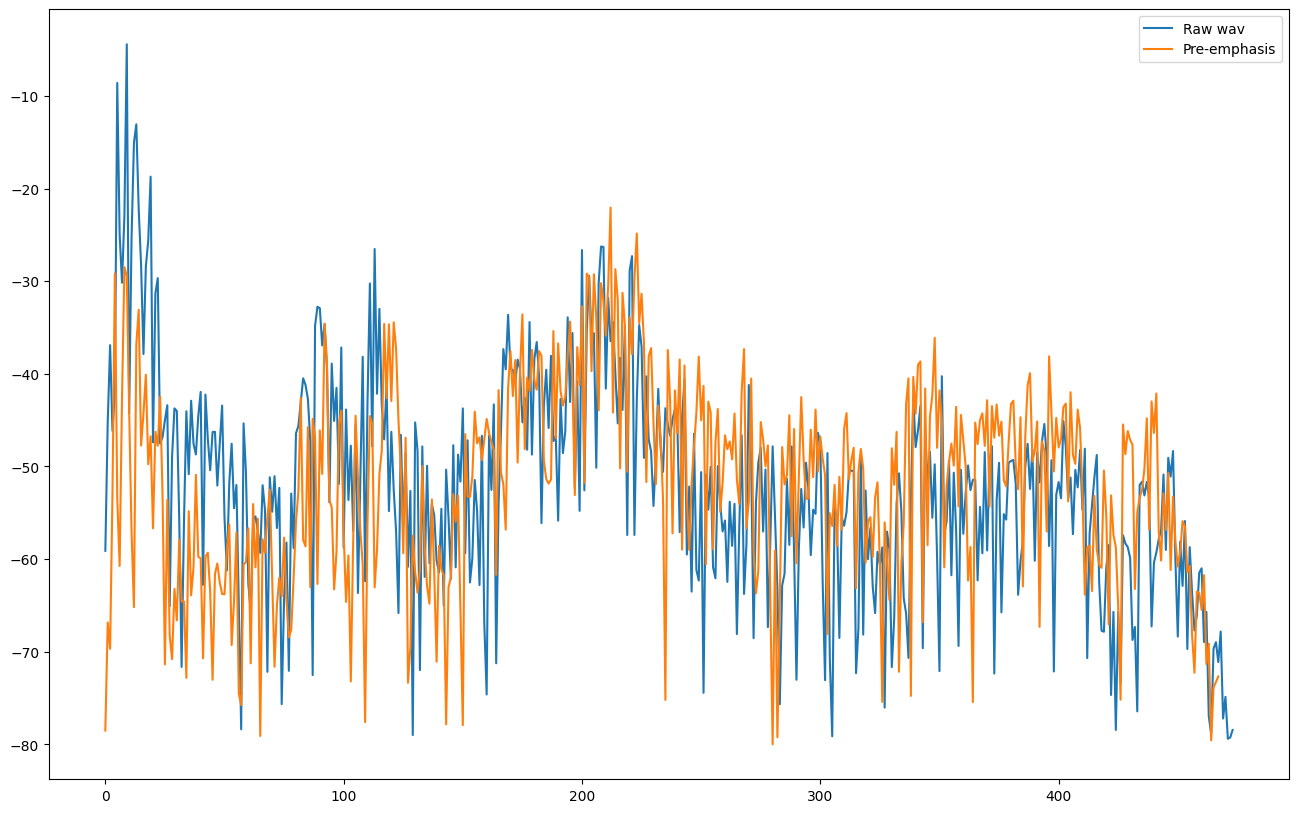

In [4]:
from scipy.fft import fft
x = ap.load_wav('./samples/00000.wav')
x_pre = ap.pre_emphasis(x)


window_size = 2000
start = 80000
window = librosa.filters.get_window('hann', window_size, fftbins=True)

x_stft = np.real(fft(x[start:start + window_size] * window))
x_stft = ap.amp_to_db(x_stft)
x_stft = x_stft[:len(x_stft)//2]
x_stft = x_stft[x_stft > -80]

x_stft_pre = np.real(fft(x_pre[start:start + window_size] * window))
x_stft_pre = ap.amp_to_db(x_stft_pre)
x_stft_pre = x_stft_pre[:len(x_stft_pre)//2]
x_stft_pre = x_stft_pre[x_stft_pre > -80]


plt.figure(figsize= (16, 10))
plt.plot(x_stft, label = 'Raw wav')
plt.plot(x_stft_pre, label = 'Pre-emphasis')
plt.legend()
plt.show()

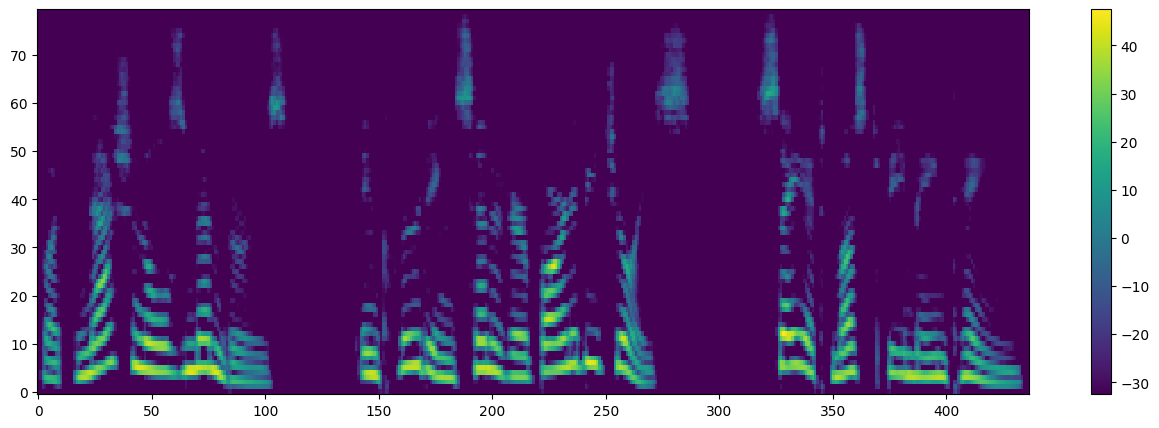

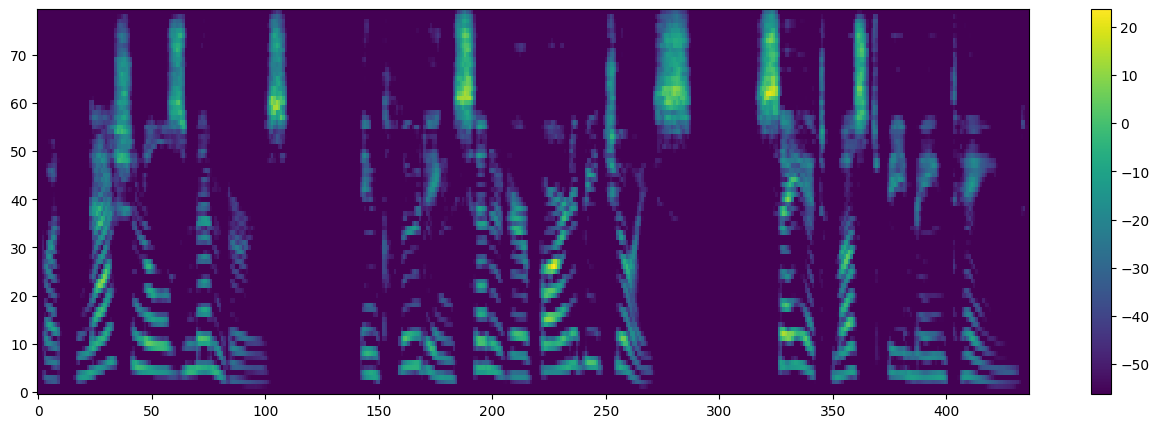

In [5]:
# Raw mel spec
x = ap.load_wav('./samples/00000.wav')
mel = librosa.amplitude_to_db(
    librosa.feature.melspectrogram(
        y=x, 
        n_mels=ap.num_mel_bins,
        sr=ap.sample_rate,
        n_fft=ap.n_fft, 
        hop_length=ap.window_step, 
        win_length=ap.window_size
    )
)

# Mel spec with preemphasis
mel_pre = librosa.amplitude_to_db(
    librosa.feature.melspectrogram(
        y=ap.pre_emphasis(x), 
        n_mels=ap.num_mel_bins,
        sr=ap.sample_rate,
        n_fft=ap.n_fft, 
        hop_length=ap.window_step, 
        win_length=ap.window_size
    )
)


plot_spectrogram(mel)
plt.show()

plot_spectrogram(mel_pre)
plt.show()

In [6]:
# check that all tests are passed

x = ap.load_wav('./samples/00000.wav')

assert np.abs(ap.de_emphasis(ap.pre_emphasis(x)) - x).max() < 1e-6

assert ap.mu_law_encode(-1.0) == 0
assert ap.mu_law_encode(0.0) == 128
assert ap.mu_law_encode(0.5) == 239
assert ap.mu_law_encode(1.0) == 255
for i in range(256):
    assert ap.mu_law_encode(ap.mu_law_decode(i)) == i

## WaveNet

<img src="./deepvoice.png" width="100%">
<img src="./wavenet.png" width="100%">

How to make our Conv layer causal?
1. Cut off padding from the right
2. Set last value of kernel window to zero

These 2 approaches are equivalent

In [7]:
# Inherit from nn.Conv1d so we reuse PyTorch's standard 1D convolution logic.
class CausalConv1d(nn.Conv1d):
    # `train` here is a custom flag:
    # - True: run on full sequences during training
    # - False: run step-by-step during autoregressive inference
    # Note: this is different from PyTorch's built-in module `.train()` / `.eval()`.
    def __init__(self, train=True, *args, **kwargs):
        # Initialize the parent Conv1d with all normal convolution parameters
        # such as in_channels, out_channels, kernel_size, dilation, etc.
        super(CausalConv1d, self).__init__(*args, **kwargs)

        # Store whether we are in "full-sequence" mode or "single-step" mode.
        self.train = train

        # For a causal convolution, output at time t must not depend on future inputs.
        # With dilation, the receptive field extends by:
        #   (kernel_size - 1) * dilation
        # time steps into the past.
        #
        # PyTorch Conv1d padding is symmetric, so we pad both sides internally,
        # then later remove the extra outputs on the right.
        self.padding = ((self.kernel_size[0] - 1) * self.dilation[0],)

    def forward(self, x):
        # Training / full-sequence mode:
        # process the whole sequence at once.
        if self.train:
            # Apply Conv1d with the padding defined above.
            x = super().forward(x)

            # Because Conv1d padded symmetrically, we get extra outputs at the end
            # that would correspond to using "future" information.
            # Remove them to make the convolution causal.
            return x[:, :, :-self.padding[0]]

        # Inference / autoregressive mode:
        # expect only the minimal input window needed to produce one new sample.
        else:

            # Effective receptive field size minus 1:
            # how many past positions are needed due to kernel width and dilation.
            dilated_kernel_size = (self.kernel_size[0] - 1) * self.dilation[0]
            
            # If the provided input window is shorter than needed,
            # add enough padding so convolution is still valid.
            if x.size(2) < (dilated_kernel_size + 1):
                self.padding = (dilated_kernel_size - x.size(2) + 1, )
            else:
                # Otherwise, the input should be exactly the required window length:
                # receptive field + current position.
                assert x.size(2) == dilated_kernel_size + 1

                # No extra padding needed in this case.
                self.padding = (0, )
            
            # Apply the convolution on this short inference window.
            x = super().forward(x)

            # If we added temporary padding, crop the extra right-side outputs again.
            if self.padding[0] != 0:
                x = x[:, :, :-self.padding[0]]

            # In autoregressive mode we expect exactly one output time step.
            assert x.size(2) == 1

            # Return the single predicted step.
            return x



class WaveNet(nn.Module):
    """WaveNet architecture with local conditioning

    https://arxiv.org/pdf/1609.03499.pdf - original paper
    https://arxiv.org/pdf/1702.07825.pdf - appending A for more details
    
    But given implementation has following differences:
    1. tanh is not applied to input embedding
    2. vector is scaled (multiplied 0.5 ** 0.5) between blocks
    3. GRU is used for processing mel spectrogram
    4. GRU output is nearest neighbour apsampled hop_size times
    5. each block has own conditioning projection

    Args:
        num_channels       (int): size of modelled categorical distribution
        residual_channels  (int): hidden vector size
        gate_channels      (int): gate block dimension
        skip_channels      (int): skip-vector size
        pre_channels       (int): dimension before the last layer
        dilation_cycles    (int): number of dilation cycles
        dilation_depth     (int): blocks number in dilation cycle
        condition_channels (int): number of mel filters
        hop_size           (int): STFT hop size
    """

    def __init__(self,
                 num_channels,
                 residual_channels,
                 gate_channels,
                 skip_channels,
                 pre_channels,
                 dilation_cycles,
                 dilation_depth,
                 condition_channels,
                 hop_size,
                 train=True):
        super(WaveNet, self).__init__()
        
        self.kernel_size = 2
        self.dilations = np.array([
            2 ** (i % dilation_depth) 
            for i in range(dilation_cycles * dilation_depth)
        ])
        
        self.num_channels = num_channels
        self.residual_channels = residual_channels
        self.gate_channels = gate_channels
        self.skip_channels = skip_channels
        self.pre_channels = pre_channels
        self.hop_size = hop_size
        
        self.condition_net = nn.GRU(
            input_size=condition_channels,
            hidden_size=condition_channels // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True)
        
        self.conv_input = nn.Conv1d(
            in_channels=num_channels,
            out_channels=residual_channels,
            kernel_size=1)

        self.blocks_conv_filter = nn.ModuleList([
            CausalConv1d(
                in_channels=residual_channels,
                out_channels=gate_channels,
                kernel_size=2,
                dilation=d,
                train=train
            ) for d in self.dilations])

        self.blocks_conv_gate = nn.ModuleList([
            CausalConv1d(
                in_channels=residual_channels,
                out_channels=gate_channels,
                kernel_size=2,
                dilation=d,
                train=train
            ) for d in self.dilations])
        
        self.blocks_conv_residual = nn.ModuleList([
            nn.Conv1d(
                in_channels=gate_channels,
                out_channels=residual_channels,
                kernel_size=1
            ) for _ in range(len(self.dilations) - 1)])
        
        self.blocks_conv_skip = nn.ModuleList([
            nn.Conv1d(
                in_channels=gate_channels,
                out_channels=skip_channels,
                kernel_size=1
            ) for _ in range(len(self.dilations))])
        
        self.blocks_conv_cond = nn.ModuleList([
            nn.Conv1d(
                in_channels=condition_channels,
                out_channels=gate_channels * 2,
                kernel_size=1
            ) for _ in range(len(self.dilations))])
        
        self.conv_out_1 = nn.Conv1d(
            in_channels=skip_channels,
            out_channels=pre_channels,
            kernel_size=1)
        self.conv_out_2 = nn.Conv1d(
            in_channels=pre_channels,
            out_channels=num_channels,
            kernel_size=1)

    def forward(self, x, c):
        """
        Args:
            x (FloatTensor): continuous audio signal [B x K x T]
            c (FloatTensor): local condition features [B x L x C],
                where L = T // 300

        Returns:
            FloatTensor: output [B x out_channels x T]
        """
        
        x = self.conv_input(x)
        c, _ = self.condition_net(c)
        c = c.transpose(1, 2)

        # Interpolate spec to target wav length (spec length * hop_size)
        c = nn.functional.interpolate(c,
            scale_factor=self.hop_size,
            mode='nearest')

        assert c.size(2) == x.size(2)

        x_acc = 0
        for b in range(len(self.dilations)):
            x_filter = self.blocks_conv_filter[b](x)
            x_gate = self.blocks_conv_gate[b](x)

            cond = self.blocks_conv_cond[b](c)
            c_filter, c_gate = cond.chunk(chunks=2, dim=1)
            x_filter += c_filter
            x_gate += c_gate

            x_hidden = torch.tanh(x_filter) * torch.sigmoid(x_gate)

            x_skip = self.blocks_conv_skip[b](x_hidden)
            x_acc = x_acc + x_skip

            if b < len(self.dilations) - 1:
                x_residual = self.blocks_conv_residual[b](x_hidden)
                x = x + x_residual

            x = x * 0.5 ** 0.5
            

        x = self.conv_out_1(torch.relu(x_acc))
        x = self.conv_out_2(torch.relu(x))

        return x

In [8]:
model = WaveNet(
    num_channels=256,
    residual_channels=64,
    gate_channels=64,
    skip_channels=128,
    pre_channels=256,
    dilation_cycles=4,
    dilation_depth=10,
    condition_channels=80,
    hop_size=300)
model.load_state_dict(torch.load('./state_dict.pth'))

<All keys matched successfully>

In [ ]:
def one_hot(x, num_channels):
    x_o = torch.FloatTensor(x.shape[0], num_channels, x.shape[1])
    x_o.zero_().scatter_(1, x.unsqueeze(1), 1)
    return x_o

def calc_loss(model, x, c):
    # Create an embedding of the input audio by one-hot encoding each sample.
    x_o = one_hot(x, model.num_channels)
    y = model.forward(x_o, c).transpose(1, 2)

    loss = nn.functional.cross_entropy(
        y[:, :-1].contiguous().view(-1, y.shape[-1]),
        x[:, 1:].contiguous().view(-1))
    
    return loss

with torch.no_grad():
    x = ap.load_wav('./samples/00000.wav')
    c = np.load('./samples/00000.npy')
    
    # cut off to be a multiple of the window step
    c = c[:len(x) // ap.window_step]
    x = x[:len(c) * ap.window_step]
    
    print (c.shape, x.shape)
    
    # apply mu-law encoding
    x = ap.mu_law_encode(x)

    x = torch.LongTensor(x)
    c = torch.FloatTensor(c)

    loss = calc_loss(model, x.unsqueeze(0), c.unsqueeze(0)).item()

assert np.allclose(loss, 1.7863293886184692)

(436, 80) (130800,)
[128. 128. 128. ... 125. 112. 109.]


# WaveNet Inference 

**Important note**: as you can see from the code, we calculate spectrograms passing them through the pre-emphasis filter. It so happened (obviously by mistake) that although WaveNet learned with such spectrograms, but the audio signal for was not passed through the pre-emphasis filter. So you **do not need** to pass WaveNet output through de-emphassis filter.

In [11]:
def prepare_condition(model, mel):
    """Run the conditioning stack once and upsample it to audio-step resolution."""
    device = next(model.parameters()).device
    dtype = next(model.parameters()).dtype
    mel = torch.as_tensor(mel, dtype=dtype, device=device)
    if mel.dim() == 2:
        mel = mel.unsqueeze(0)
    mel, _ = model.condition_net(mel)
    mel = mel.transpose(1, 2)
    return F.interpolate(mel, scale_factor=model.hop_size, mode='nearest')

In [ ]:
class FastInferenceState:
    """Cached weights and ring buffers for fast batch-1 autoregressive inference."""
    def __init__(self, model, mel):
        self.model = model
        self.mel = mel
        self.device = mel.device
        self.dtype = mel.dtype
        self.dilations = [int(d) for d in model.dilations]
        self.scale = 0.5 ** 0.5
        self.input_weight = model.conv_input.weight[:, :, 0].t().contiguous()
        self.input_bias = model.conv_input.bias.contiguous()
        self.filter_prev = [conv.weight[:, :, 0].contiguous() for conv in model.blocks_conv_filter]
        self.filter_curr = [conv.weight[:, :, 1].contiguous() for conv in model.blocks_conv_filter]
        self.filter_bias = [conv.bias.contiguous() for conv in model.blocks_conv_filter]
        self.gate_prev = [conv.weight[:, :, 0].contiguous() for conv in model.blocks_conv_gate]
        self.gate_curr = [conv.weight[:, :, 1].contiguous() for conv in model.blocks_conv_gate]
        self.gate_bias = [conv.bias.contiguous() for conv in model.blocks_conv_gate]
        self.cond_weight = [conv.weight[:, :, 0].contiguous() for conv in model.blocks_conv_cond]
        self.cond_bias = [conv.bias.contiguous() for conv in model.blocks_conv_cond]
        self.skip_weight = [conv.weight[:, :, 0].contiguous() for conv in model.blocks_conv_skip]
        self.skip_bias = [conv.bias.contiguous() for conv in model.blocks_conv_skip]
        self.res_weight = [conv.weight[:, :, 0].contiguous() for conv in model.blocks_conv_residual]
        self.res_bias = [conv.bias.contiguous() for conv in model.blocks_conv_residual]
        self.out1_weight = model.conv_out_1.weight[:, :, 0].contiguous()
        self.out1_bias = model.conv_out_1.bias.contiguous()
        self.out2_weight = model.conv_out_2.weight[:, :, 0].contiguous()
        self.out2_bias = model.conv_out_2.bias.contiguous()
        self.buffers = [
            torch.zeros(d, model.residual_channels, device=self.device, dtype=self.dtype)
            for d in self.dilations
        ]
        self.indices = [0 for _ in self.dilations]

    def input_projection(self, token):
        # A 1x1 conv over a one-hot token is just an embedding lookup plus bias.
        return self.input_weight[int(token)] + self.input_bias

    def block_step(self, block_index, x, cond):
        # `x_input` is the exact tensor that enters this residual block at the current time step.
        # We keep a separate name for it because later:
        # 1. it contributes to the "current" part of the dilated convolution,
        # 2. it is the value we must push into the ring buffer,
        # 3. it is also the tensor used in the residual connection `x_input + residual(...)`.
        x_input = x
        index = self.indices[block_index]

        # Each block has its own circular buffer of length `dilation`.
        # The current write position always points at the value that was written exactly
        # `dilation` steps ago, so reading `buffers[block_index][index]` gives us the
        # delayed sample that the original dilated Conv1d would have seen through its
        # left kernel tap.
        delayed = self.buffers[block_index][index]

        # In the train version we applied `blocks_conv_cond[b]` to the whole upsampled mel
        # sequence and then selected the current time step.
        # Here we do the same computation only for the current frame `cond`.
        #
        # The conditioning projection outputs `2 * gate_channels` values because it
        # provides separate additive terms for the filter branch and the gate branch.
        cond = F.linear(cond, self.cond_weight[block_index], self.cond_bias[block_index])
        c_filter, c_gate = cond.chunk(2)

        # `kernel_size = 2` means the dilated convolution at this step is just:
        #   W_prev * delayed + W_curr * current + bias
        #
        # So instead of calling Conv1d on a tiny `[channels x 2]` window, we apply the two
        # weight slices explicitly:
        # - `*_prev` is the contribution from the sample `dilation` steps назад
        # - `*_curr` is the contribution from the current sample
        #
        # This is mathematically the same as the original convolution, but much cheaper in
        # autoregressive batch-1 inference.
        x_filter = F.linear(delayed, self.filter_prev[block_index], self.filter_bias[block_index])
        x_filter = x_filter + F.linear(x_input, self.filter_curr[block_index])
        x_gate = F.linear(delayed, self.gate_prev[block_index], self.gate_bias[block_index])
        x_gate = x_gate + F.linear(x_input, self.gate_curr[block_index])

        # This is the standard WaveNet gated activation:
        #   tanh(filter + cond_filter) * sigmoid(gate + cond_gate)
        #
        # After that we compute the skip connection exactly as in the original block.
        x_hidden = torch.tanh(x_filter + c_filter) * torch.sigmoid(x_gate + c_gate)
        x_skip = F.linear(x_hidden, self.skip_weight[block_index], self.skip_bias[block_index])

        # All blocks except the last one also produce a residual update.
        # We add it to the original block input, not to an already modified tensor,
        #   x = x_input + residual(x_hidden)
        if block_index < len(self.dilations) - 1:
            x = x_input + F.linear(x_hidden, self.res_weight[block_index], self.res_bias[block_index])

        # Important order:
        # 1. first read the delayed value,
        # 2. only then overwrite this slot with the current block input,
        # 3. advance the pointer modulo `dilation`.
        #
        # Because of that, on the next wrap-around this slot will again contain the value
        # from exactly `dilation` steps in the past.
        self.buffers[block_index][index] = x_input
        self.indices[block_index] = (index + 1) % self.dilations[block_index]

        # Just like in the original network, the residual stream is scaled between blocks.
        # We return:
        # - the next residual-state tensor for the following block
        # - the skip contribution that will be accumulated outside this method
        return x * self.scale, x_skip

    def output_projection(self, x_acc):
        # Final pair of 1x1 output heads from the original model.
        x = F.linear(torch.relu(x_acc), self.out1_weight, self.out1_bias)
        return F.linear(torch.relu(x), self.out2_weight, self.out2_bias)


def infer(model, mel, initial_token=128, show_progress=True):
    """Fast inference with the same high-level flow as the original notebook code."""
    with torch.no_grad():
        mel = prepare_condition(model, mel)
        storage = FastInferenceState(model, mel)
        generated = torch.empty(mel.size(2) + 1, dtype=torch.long, device=mel.device)
        generated[0] = initial_token

        iterator = tqdm(range(mel.size(2))) if show_progress else range(mel.size(2))
        for i in iterator:
            # Same outer loop as before: previous token -> WaveNet blocks -> sample next token.
            x = storage.input_projection(generated[i])
            x_acc = torch.zeros(model.skip_channels, device=mel.device, dtype=mel.dtype)
            cond = mel[0, :, i]

            for b in range(len(model.dilations)):
                x, x_skip = storage.block_step(b, x, cond)
                x_acc = x_acc + x_skip

            x = storage.output_projection(x_acc)
            generated[i + 1] = torch.multinomial(torch.softmax(x, dim=0), 1)

        return generated.unsqueeze(0)

In [14]:
model = WaveNet(
    num_channels=256,
    residual_channels=64,
    gate_channels=64,
    skip_channels=128,
    pre_channels=256,
    dilation_cycles=4,
    dilation_depth=10,
    condition_channels=80,
    hop_size=300,
    train=False)
model.load_state_dict(torch.load('./state_dict.pth'))



<All keys matched successfully>

In [20]:
mel.shape

(130979,)

In [24]:

mel = np.load('./samples/00000.npy')
generated = infer(model, mel, show_progress=True)

100%|██████████| 131100/131100 [04:08<00:00, 527.08it/s]


In [25]:
x = ap.load_wav('./samples/00000.wav')
x_gen = ap.mu_law_decode(generated.squeeze(0).cpu().numpy())

display(Audio(x, rate=ap.sample_rate))
display(Audio(x_gen.reshape(-1, ), rate=ap.sample_rate))

In [ ]:
sf.write('./samples/gen.wav', x_gen.reshape(-1, ), ap.sample_rate)

In [ ]:
wav, sr = sf.read('./samples/gen.wav')
display(Audio(wav.reshape(-1, ), rate=ap.sample_rate))